# Dataset description :
student_id – Unique identifier for each student

age – Age of the student

gender – Student gender

cgpa – Academic performance score (4.5 to 10 scale)

branch – Field of study (CSE, IT, ECE, Mechanical, etc.)

college_tier – College tier classification

attendance_percentage – Attendance rate

backlogs – Number of academic backlogs

study_hours_per_day – Daily study hours

Technical Skills and Experience

coding_skill_score – Programming skill level

aptitude_score – Aptitude test score

logical_reasoning_score – Logical reasoning ability

certifications_count – Number of certifications completed

projects_count – Number of projects completed

github_repos – Number of GitHub repositories

internships_count – Number of internships completed

Professional and Communication Skills

communication_skill_score – Communication ability

mock_interview_score – Mock interview performance

linkedin_connections – Number of LinkedIn connections

Personal and Extracurricular Factors

extracurricular_score – Extracurricular participation score

leadership_score – Leadership ability score

volunteer_experience – Volunteer experience (Yes/No)

sleep_hours – Average sleep duration

placement_status – Indicates whether the student got offered a job

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score

## 1. Loading the dataset

In [20]:
import os

data_path = "student.csv"
df = pd.read_csv(data_path)
print("Using dataset:", data_path)
print("Shape:", df.shape)

display(df.head())

Using dataset: student.csv
Shape: (100000, 26)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In our predictions the ID's of the student won't affect our outcomes, thus we are able to remove this feature. More over salary is only set for placed students (got offered a job) it will also be removed.

In [21]:
df.drop(columns=["student_id"], inplace=True)
df.drop(columns=["salary_package_lpa"], inplace=True)

## 2. Dataset Overview

We check for:
- data types
- missing values
- duplicates

In [22]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  int64  
 1   gender                     100000 non-null  str    
 2   cgpa                       100000 non-null  float64
 3   branch                     100000 non-null  str    
 4   college_tier               100000 non-null  str    
 5   internships_count          100000 non-null  int64  
 6   projects_count             100000 non-null  int64  
 7   certifications_count       100000 non-null  int64  
 8   coding_skill_score         100000 non-null  float64
 9   aptitude_score             100000 non-null  float64
 10  communication_skill_score  100000 non-null  float64
 11  logical_reasoning_score    100000 non-null  float64
 12  hackathons_participated    100000 non-null  int64  
 13  github_repos               100000 non-nul

None

We can obviously see that no values are missing so it isn't needed to use any data imputation.

In [23]:
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count"))


Missing values per column:


,missing_count
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0
aptitude_score,0


In [24]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,21.00574,1.999562,18.0,19.0,21.0,23.0,24.0
gender,100000,2,Male,60028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cgpa,100000.0,NaN,NaN,NaN,7.49689,0.992834,4.5,6.82,7.5,8.18,10.0
branch,100000,6,CSE,34818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
college_tier,100000,3,Tier 2,49955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internships_count,100000.0,NaN,NaN,NaN,1.50223,1.22528,0.0,1.0,1.0,2.0,8.0
projects_count,100000.0,NaN,NaN,NaN,3.00186,1.731764,0.0,2.0,3.0,4.0,13.0
certifications_count,100000.0,NaN,NaN,NaN,2.00515,1.416553,0.0,1.0,2.0,3.0,11.0
coding_skill_score,100000.0,NaN,NaN,NaN,69.825326,14.694618,20.0,59.807945,70.00625,80.058762,100.0
aptitude_score,100000.0,NaN,NaN,NaN,64.988108,14.844093,20.0,54.8946,65.011394,75.079266,100.0


## 3. Exploratory Data Analysis (EDA)

We will explore:
- the distribution of the target `charges`
- distributions of numerical features
- counts of categorical features
- relationships between features and target
- correlation structure among numerical features


In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']
Categorical columns: ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']


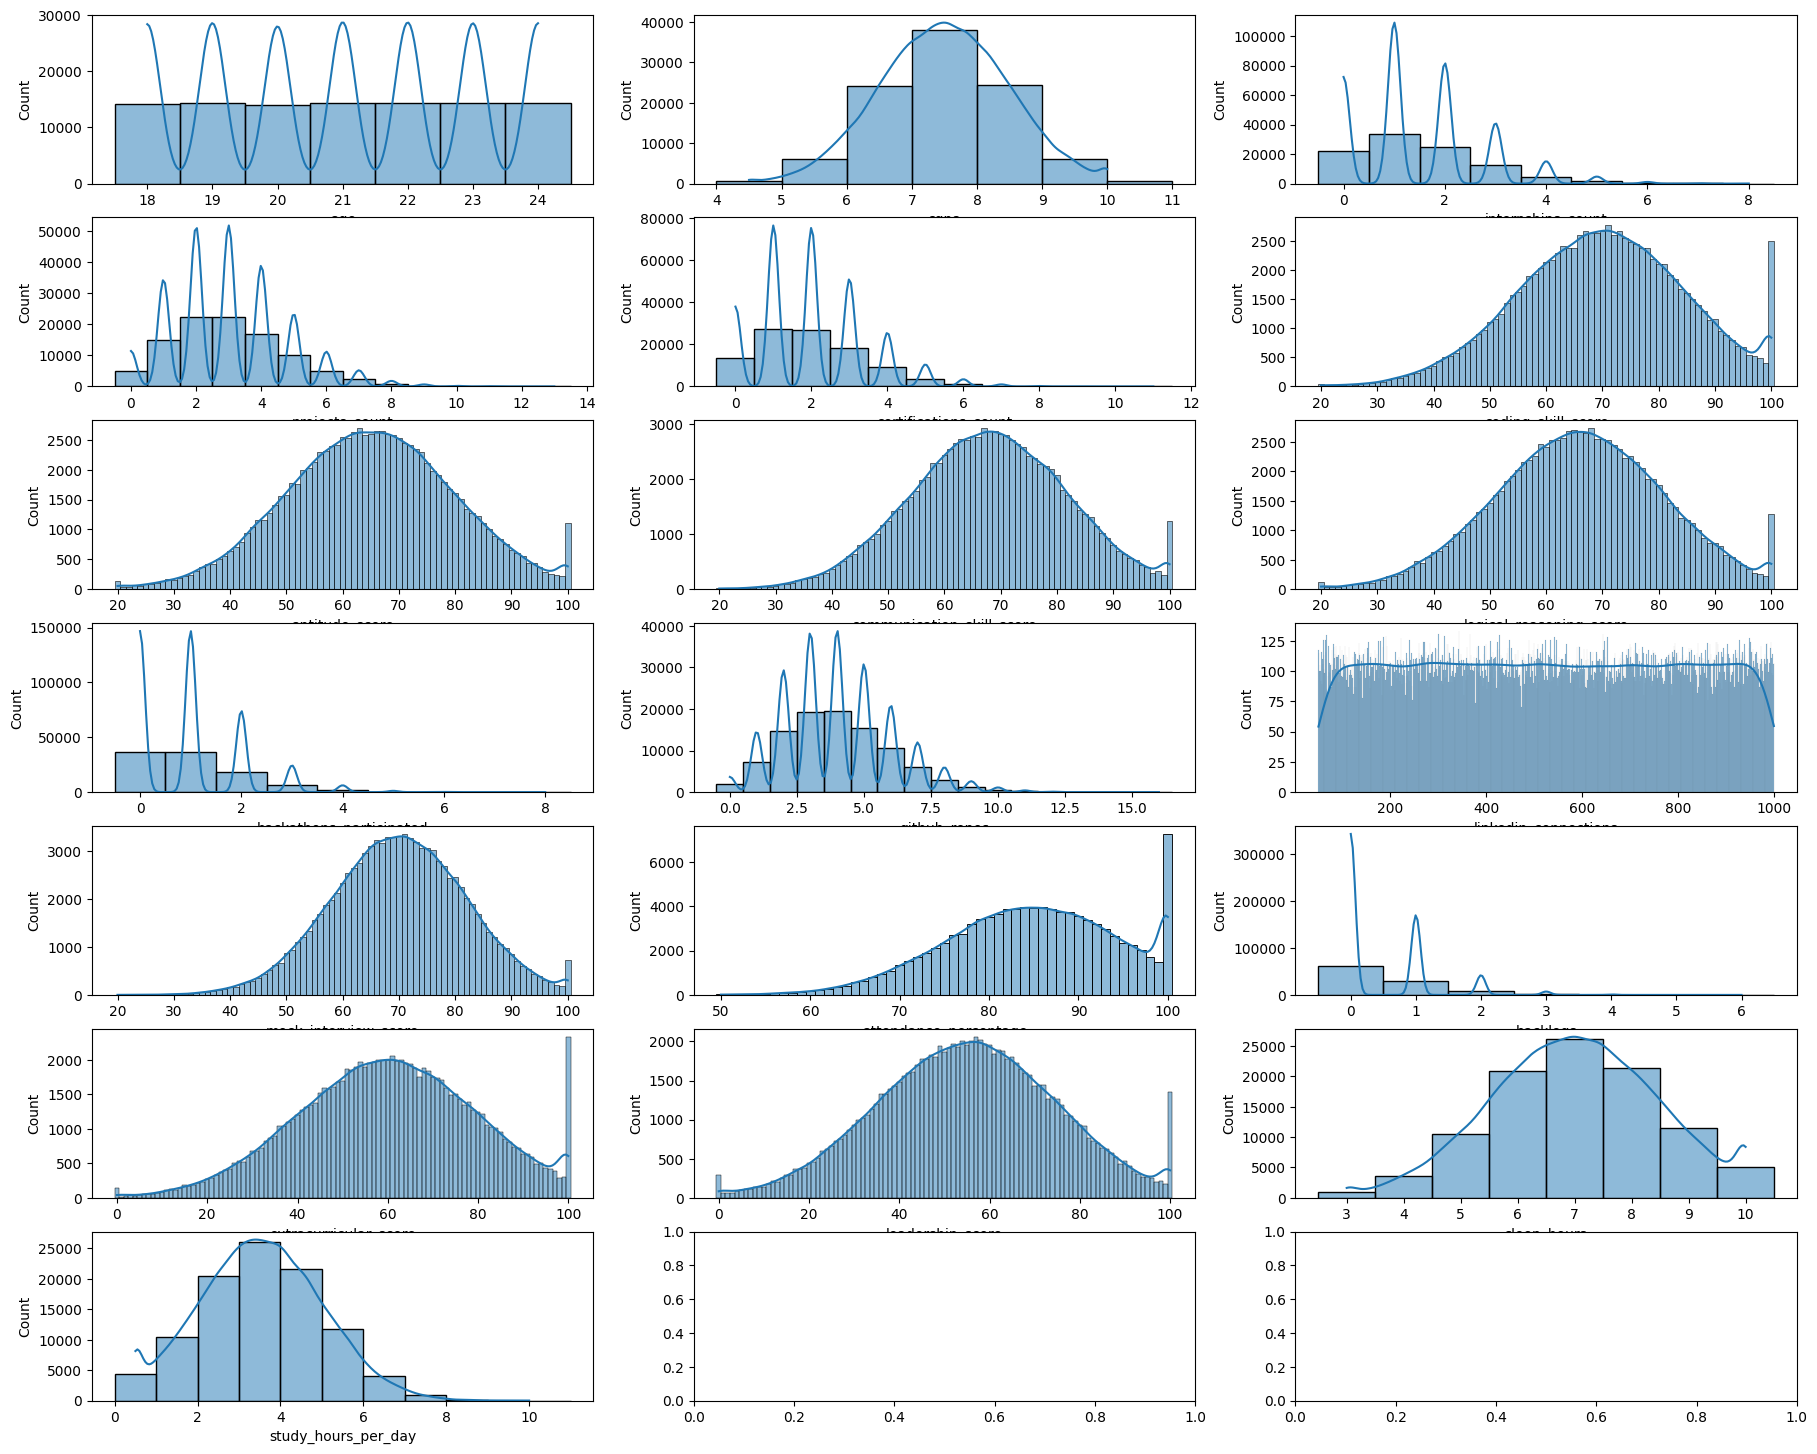

In [43]:
# Histograms for numerical features
n_rows, n_cols = 7, 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 18))

for i, column in enumerate(numeric_cols):
    sns.histplot(df[column],ax=axes[i//n_cols,i%n_cols], kde=True, discrete=True)